In [2]:
import numpy as np
import struct
import matplotlib.pyplot as plt
import os 

import pandas as pd 
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso, LassoCV
from sklearn.linear_model import RidgeClassifierCV
from sklearn.linear_model import RidgeClassifier


import seaborn as sns

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA 

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report


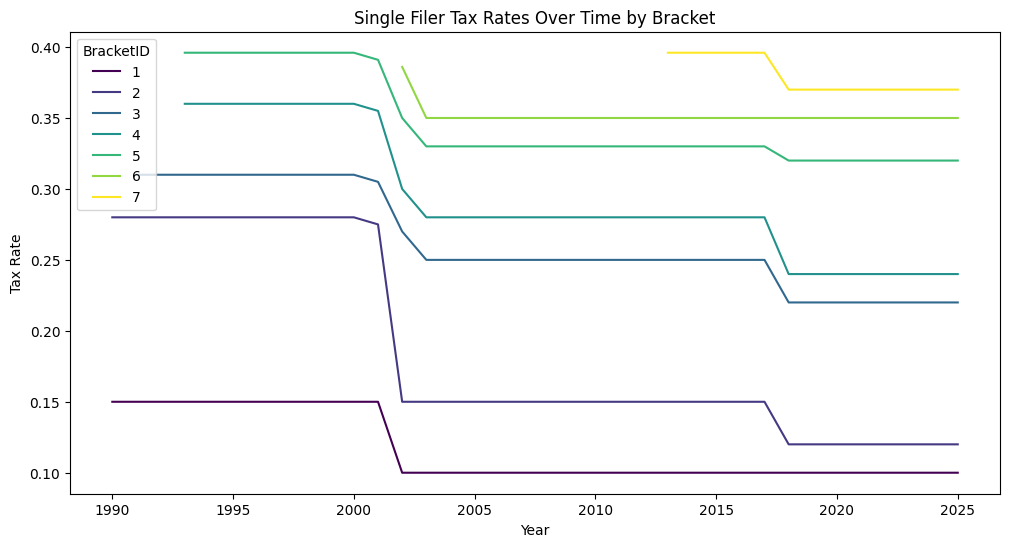

Test Tax Rate: 0.12
IRA Acc ballance at end: 821611.9607473612
Reinvested additional money saved from tax deductions under IRA acc 379755.27175650967
ROTH IRA Acc ballance at end: 1264018.4011497865
IRA_final_bankacc - ROTH_IRA_final_bank acc 64785.0
ROTH_IRA account value - IRA account value 404485.8883679318


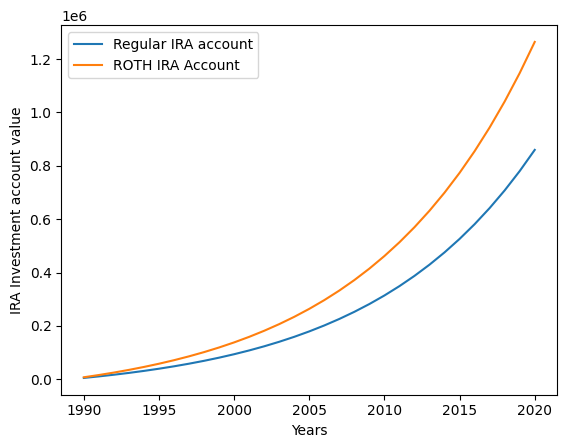

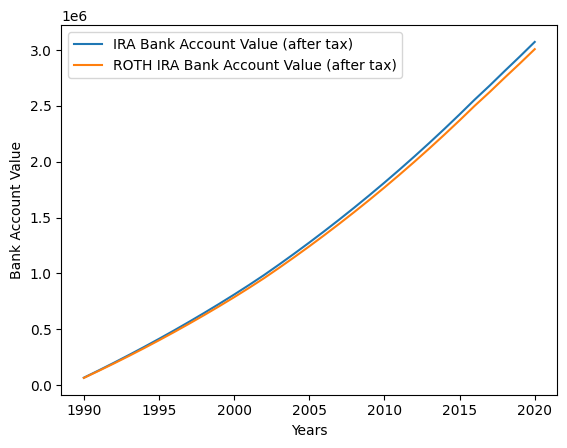

In [ ]:
data = "YOUR_FILE_NAME_HERE"

df = pd.read_csv(data)


df = df.drop(columns =["Unnamed: 2", "Unnamed: 5", "Unnamed: 8", "Unnamed: 11", "Notes:"])



df["Year"] = pd.to_numeric(df["Year"], errors="coerce") 

df = df[df["Year"] >= 1990] 

df = df.rename(columns ={"Unnamed: 3" : "Income Range Married Filling Jointly", "Unnamed: 6" : "Income Range Married Filling Separately", "Unnamed: 9" : "Income Range Single Filer", "Unnamed: 12" : "Income Range Head of Household"}) 

cols = ["Income Range Married Filling Jointly", "Income Range Married Filling Separately", "Income Range Single Filer", "Income Range Head of Household"]

for c in cols:
    df[c] = (
        df[c]
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("(", "-", regex=False)
        .str.replace(")", "", regex=False)
        .astype(float)
    )

cols = ["Married Filing Jointly (Rates/Brackets)", "Married Filing Separately (Rates/Brackets)", "Single Filer (Rates/Brackets)", "Head of Household (Rates/Brackets)"]

for c in cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.replace("%", "", regex=False)
        .astype(float)
        *0.01
    )

df["BracketID"] = df.groupby("Year").cumcount() + 1

plt.figure(figsize=(12, 6))

sns.lineplot(data = df, x = "Year", y = "Single Filer (Rates/Brackets)", hue="BracketID", palette = "viridis")
plt.title("Single Filer Tax Rates Over Time by Bracket") 
plt.ylabel("Tax Rate") 

plt.show() 




def get_tax_rate(df, year, income): 
    year_df = df[df["Year"] == year] 

    bracket_row = year_df[year_df["Income Range Single Filer"] <= income].iloc[-1] 

    return bracket_row["Single Filer (Rates/Brackets)"]

print('Test Tax Rate:', get_tax_rate(df, 2025, 20000))

def income_func(starting_salary, duration): 
    incomes = [] 
    current = starting_salary
    for _ in range(duration): 
        incomes.append(current)
        current *= 1.025 
    return incomes

def taxed_income_ira(df, start_year, end_year, starting_salary): 
    duration = end_year - start_year  
    incomes = income_func(starting_salary, duration)
    years =np.arange(start_year, end_year + 1, 1)
    taxed_income = [] 
    for income, year in zip(incomes, years): 
        fed_income_tax = get_tax_rate(df, year, income)
        tax_income_val = (income-7000)*(1-fed_income_tax)
        taxed_income.append(tax_income_val)

    return taxed_income

def taxed_income_roth_ira(df, start_year, end_year, starting_salary): 
    duration = end_year - start_year  
    incomes = income_func(starting_salary, duration)
    years =np.arange(start_year, end_year + 1, 1)
    taxed_income = [] 
    for income, year in zip(incomes, years): 
        fed_income_tax = get_tax_rate(df, year, income)
        tax_income_val = (income)*(1-fed_income_tax) - 7000 
        taxed_income.append(tax_income_val)

    return taxed_income


def ira_sim(df, starting_salary, start_year, end_year, ira_limit = 7000, salary_growth = 0.025, investment_growth = 0.095): 
    duration = end_year - start_year
    incomes = income_func(starting_salary, duration) 
    ira_balance = 0 
    ira_balance_list = [] 
    tax_savings_balance = 0 

    for i, income in enumerate(incomes): 
        year = start_year + i 

        tax_rate = get_tax_rate(df, year, income) 

        contribution = min(ira_limit, income) 

        tax_saved = contribution * tax_rate

        ira_balance = (ira_balance + contribution) * (1 + investment_growth) 
        tax_savings_balance = (tax_savings_balance + tax_saved) * (1 + investment_growth) 
        ira_balance_list.append(ira_balance) 
    
    final_tax = get_tax_rate(df, end_year, incomes[-1]) 

    ira_balance = ira_balance*(1-final_tax) 
    return ira_balance, tax_savings_balance, ira_balance_list

def roth_ira_sim(starting_salary, start_year, end_year, ira_limit = 7000, salary_growth = 0.025, investment_growth = 0.095): 
    duration = end_year - start_year
    incomes = income_func(starting_salary, duration) 
    ira_balance = 0 
    ira_balance_list = [] 
    for i, income in enumerate(incomes): 
            year = start_year + i  

            contribution = min(ira_limit, income) 

            ira_balance = (ira_balance + contribution) * (1 + investment_growth) 
            ira_balance_list.append(ira_balance) 

    return ira_balance, ira_balance_list

starting_income = 100000

ira_balance, tax_savings_balance, ira_balance_list = ira_sim(df, starting_income, 1990, 2021) 

roth_ira_balance, roth_ira_balance_list = roth_ira_sim(starting_income, 1990, 2021) 

incomes = income_func(starting_income, 21) 

final_tax = get_tax_rate(df, 2020, incomes[-1]) 

ira_incomes = taxed_income_ira(df, 1990, 2021, starting_income)

roth_ira_incomes = taxed_income_roth_ira(df, 1990, 2021, starting_income)

plt.figure()
plt.plot(np.arange(1990, 2021, 1), np.array(ira_balance_list)*(1-final_tax), label='Regular IRA account')
plt.plot(np.arange(1990, 2021, 1), np.array(roth_ira_balance_list), label = 'ROTH IRA Account')
plt.legend()
plt.ylabel('IRA Investment account value')
plt.xlabel('Years')

plt.figure()
plt.plot(np.arange(1990, 2021, 1), np.array(ira_incomes).cumsum(), label='IRA Bank Account Value (after tax)') 
plt.plot(np.arange(1990, 2021, 1), np.array(roth_ira_incomes).cumsum(), label='ROTH IRA Bank Account Value (after tax)') 
plt.legend()
plt.ylabel('Bank Account Value')
plt.xlabel('Years')



print('IRA Acc ballance at end:', ira_balance)
print('Reinvested additional money saved from tax deductions under IRA acc', tax_savings_balance)
print('ROTH IRA Acc ballance at end:', roth_ira_balance)

print("IRA_final_bankacc - ROTH_IRA_final_bank acc", (np.array(ira_incomes).cumsum()[-1]- np.array(roth_ira_incomes).cumsum()[-1]))
print("ROTH_IRA account value - IRA account value",np.array(roth_ira_balance_list)[-1] - np.array(ira_balance_list)[-1] * (1 - final_tax))
